A/A test

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import gc # пришлось импортировать garbage collector, потому что колаб ложился

In [ ]:
np. random.seed(43)

sns.set_theme(style='whitegrid')

используем только тест уэлча, т.к. в реальности мы не знаем истинной дисперсии. тест уэлча для всех трех распределений будет переменная объект под тип распределения.

In [ ]:

  # по DRY новая run_aa_test и def data_generator
def data_generator(type_dist, n_samples_both, split_ratio, mde=0,
                   p_conversion = 0.1, mu_normal = 100, sigma_normal = 15,
                   lambda_expon = 10):
  """
  обязательно для аб тестов разные mde помещать
  по стандарту mde = 0
  split_ratio - это долевое отношение контроля к тестовому
  """
  if type_dist == "binom":
    samples_control = stats.binom.rvs(n=1, p=p_conversion, size = int(n_samples_both * split_ratio))
    samples_test = stats.binom.rvs(n=1, p=p_conversion + mde, size = int(n_samples_both * split_ratio))
  if type_dist == "norm":
    samples_control = stats.norm.rvs(loc=mu_normal, scale=sigma_normal, size = int(n_samples_both * split_ratio))
    samples_test = stats.norm.rvs(loc=mu_normal + mde, scale=sigma_normal, size = int(n_samples_both * (1 - split_ratio)))
  if type_dist == "expon":
    samples_control = stats.expon.rvs(scale = lambda_expon, size = int(n_samples_both * split_ratio))
    samples_test = stats.expon.rvs(scale = lambda_expon + mde, size = int(n_samples_both * (1-split_ratio)))
  return samples_control, samples_test


def run_aa_test(n_simulations: int, data_generator, alpha: float = 0.05):
  p_values = []

  for i in tqdm(range(n_simulations), desc="Запуск АА теста"):
      samples_control, samples_test = data_generator()

      _, p_val = stats.ttest_ind(samples_control, samples_test, equal_var=False)
      p_values.append(p_val)

      #заставляем garbadge collector почистить массивы
      # del samples_control, samples_test

  # посчитаем эмпирическую ошибку первого рода False Positive Rate
  # попался на том, что gc.collect() поместил внуть цикла и оч долго считалось
  # gc.collect()
  # upd garbadge ещё хуже тормозил
  fpr = np.mean(np.array(p_values) < alpha)
  return p_values, fpr




логика графиков


In [ ]:
def plot_results(p_values, dist_type, split_str, fpr, alpha=0.05):
    """
    Строит графики распределения p-value и QQ-plot.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    title_base = f"Dist: {dist_type} | Split: {split_str} | FPR (Type I): {fpr:.4f}"

    # 1. Гистограмма P-values
    sns.histplot(p_values, bins=20, stat='density', kde=False, ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].axhline(1.0, color='red', linestyle='--', label='Theoretical Uniform')
    axes[0].axvline(alpha, color='green', linestyle='--', label=f'alpha={alpha}')
    axes[0].set_title(f"P-value Histogram\n{title_base}")
    axes[0].set_xlabel("P-value")
    axes[0].set_ylabel("Density")
    axes[0].legend()
    axes[0].set_xlim(0, 1)

    # 2. QQ-plot (Uniform)
    stats.probplot(p_values, dist="uniform", plot=axes[1])
    axes[1].get_lines()[1].set_color('red')
    axes[1].set_title(f"QQ-plot (vs Uniform)\nShould be on red line")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def plot_ecdf(p_values, dist_type, split_str, fpr, alpha=0.05):
    """
    Строит ECDF plot для p-values.
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    # Сортируем p-value для построения ECDF
    sorted_p = np.sort(p_values)
    # Накопленная доля: 1/n, 2/n, ..., n/n
    ecdf = np.arange(1, len(sorted_p) + 1) / len(sorted_p)

    # Рисуем эмпирическую ECDF
    ax.plot(sorted_p, ecdf, label='Empirical ECDF', linewidth=2, color='steelblue')

    # Рисуем теоретическую диагональ (Uniform[0,1])
    ax.plot([0, 1], [0, 1], 'r--', label='Theoretical (Uniform)', linewidth=2)

    # Показываем точку на уровне alpha
    ax.axvline(alpha, color='green', linestyle='--', alpha=0.5, label=f'alpha={alpha}')
    ax.axhline(alpha, color='green', linestyle='--', alpha=0.5)

    ax.set_xlabel('p-value')
    ax.set_ylabel('Cumulative Proportion')
    ax.set_title(f'ECDF Plot\nDist: {dist_type} | Split: {split_str} | FPR: {fpr:.4f}')
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close(fig)


Поведение АА теста для трех распределений с соотношением 50 на 50

In [ ]:

# это был старый код до изменений run_aa_test, костыль снизу, чтобы не переписывать 1/3 ноутбука
results_50_50 = []

n_simulations, n_samples_total, split_ratio, alpha = 10000, 5000, 0.5, 0.05
# сам костыль
dist_names_mapping = {
    'binom': 'Binomial',
    'norm': 'Normal',
    'expon': 'Exponential'
}

for dist_key, nice_name in dist_names_mapping.items():

    # костыль
    current_generator = lambda d=dist_key: data_generator(
        type_dist=d,
        n_samples_both=n_samples_total,
        split_ratio=split_ratio,
        mde=0.0 # mde == 0.0 потому шо аа тест
    )

    # Теперь передаем в тест ТОЛЬКО то, что он просит: кол-во симуляций, генератор и альфу
    print(f"\nЗапуск симуляции для {nice_name}...")
    # получилось теперь, что current_generator вносит 3 переменных,
    # когда раньше в run_aa_test вносилось целых пять
    p_values, fpr = run_aa_test(n_simulations, current_generator, alpha)
    # раньше
    results_50_50.append((nice_name, p_values, fpr))


Запуск симуляции для Binomial...


Запуск АА теста: 100%|██████████| 10000/10000 [00:18<00:00, 549.78it/s]



Запуск симуляции для Normal...


Запуск АА теста: 100%|██████████| 10000/10000 [00:20<00:00, 493.40it/s]



Запуск симуляции для Exponential...


Запуск АА теста: 100%|██████████| 10000/10000 [00:21<00:00, 455.10it/s]


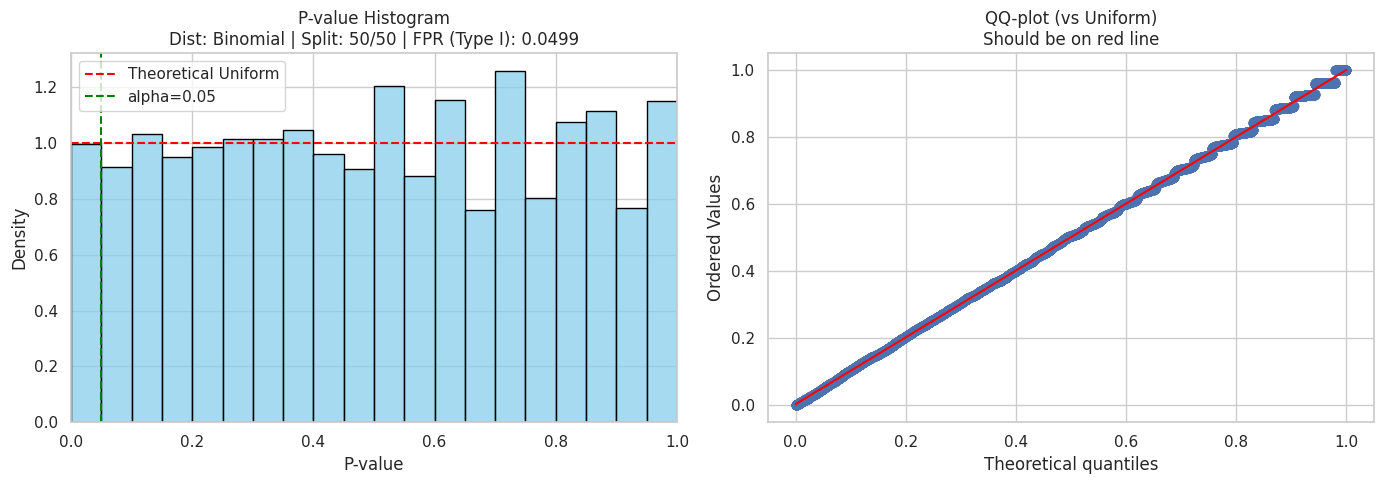

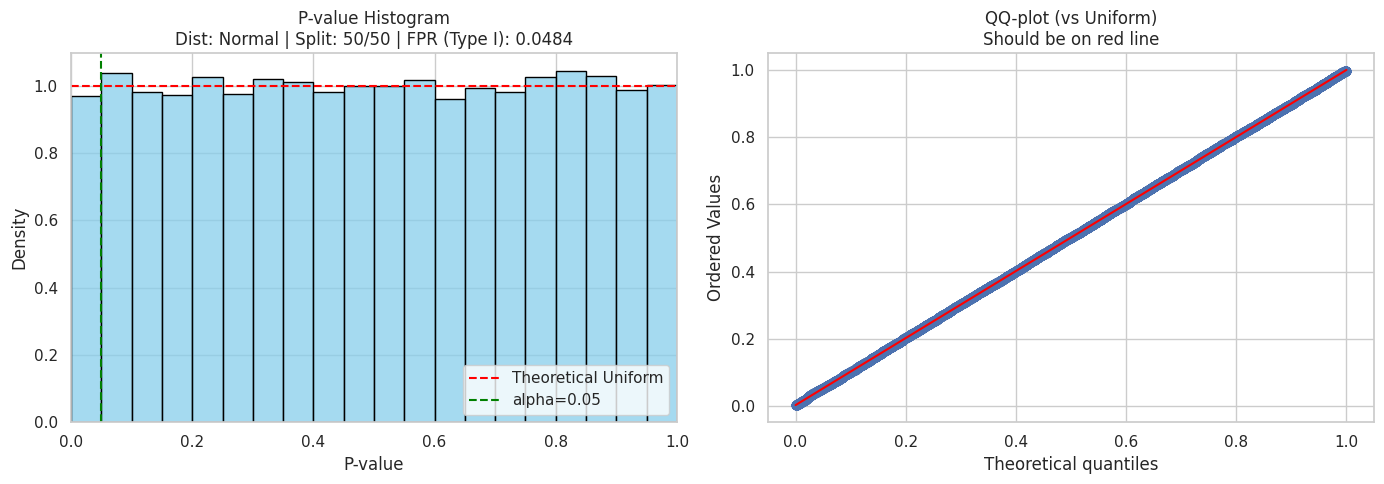

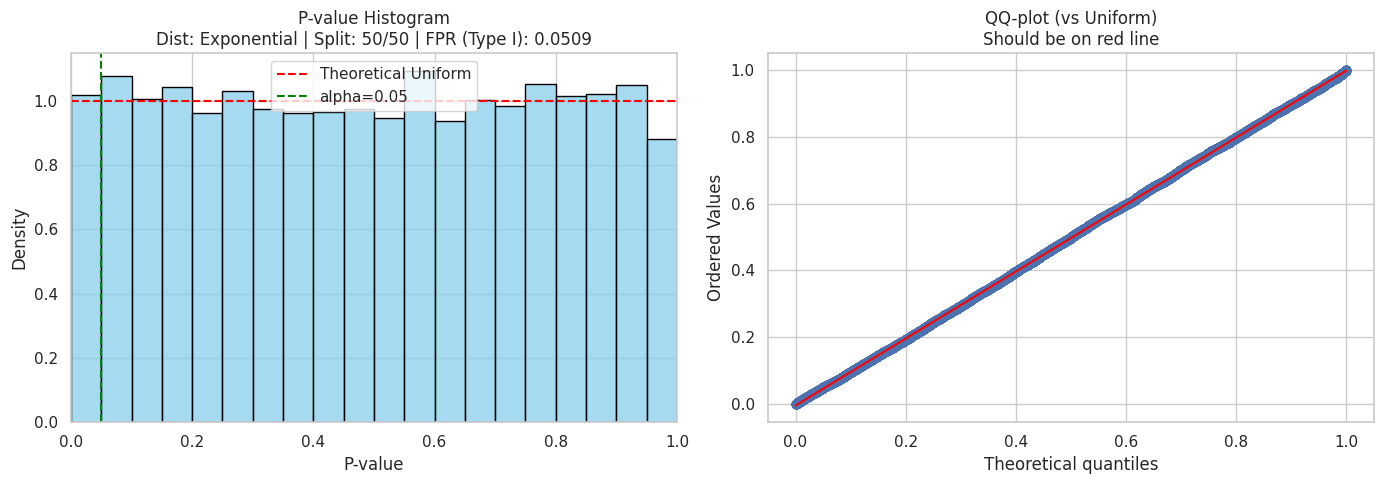

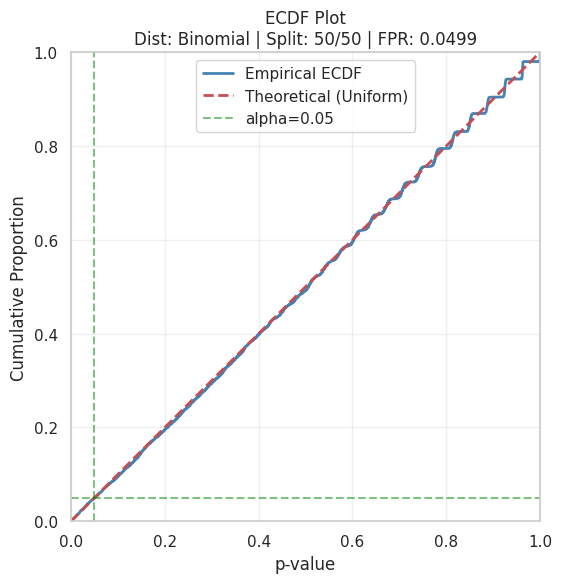

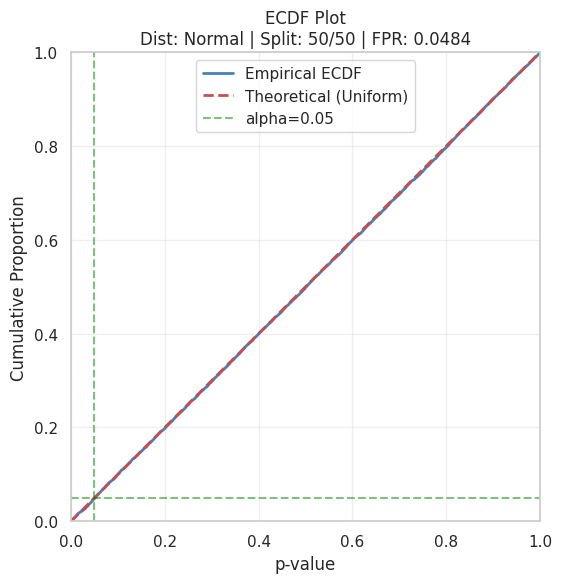

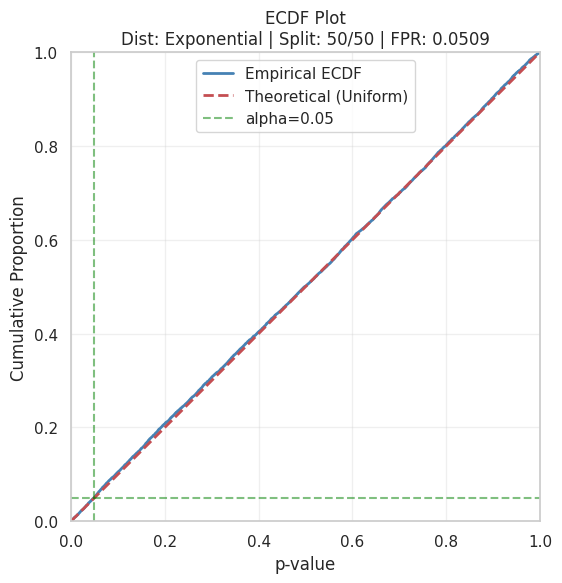

In [ ]:
# рисовка графичков

dist_names = ['Binomial', 'Normal', 'Exponential']
split_str = '50/50'
alpha = 0.05

# ГРАФИК НА ОШИБКУ ПЕРВОГО РОДА
for nice_name, p_values, fpr in results_50_50:
    plot_results(p_values, nice_name, split_str, fpr, alpha=alpha)
# ГРАФИК НА ECDF
for nice_name, p_values, fpr in results_50_50:
    plot_ecdf(p_values, nice_name, split_str, fpr, alpha=alpha)

АА тест с разбивкой 10 на 90. 10% control, 90% test

In [ ]:
results_10_90 = []

n_simulations, n_samples_total, split_ratio, alpha = 10000, 5000, 0.1, 0.05 # split ratio = 0.1 - доля контроля
"""
for dist_object in [binom, norm, expon]:
  dist_object = dist_object
  p_values, fpr = run_aa_test(n_simulations, n_samples_total, split_ratio, dist_object, alpha)
  results_10_90.append((dist_object, p_values, fpr))
"""
# снова костыль
for dist_key, nice_name in dist_names_mapping.items():
    current_generator = lambda d=dist_key: data_generator(
        type_dist=d,
        n_samples_both=n_samples_total,
        split_ratio=split_ratio,
        mde=0.0 # mde == 0.0 потому шо аа тест
    )
    print(f"\nЗапуск симуляции для {nice_name}...")
    p_values, fpr = run_aa_test(n_simulations, current_generator, alpha)
    results_10_90.append((nice_name, p_values, fpr))


Запуск симуляции для Binomial...


Запуск АА теста: 100%|██████████| 10000/10000 [00:22<00:00, 436.27it/s]



Запуск симуляции для Normal...


Запуск АА теста: 100%|██████████| 10000/10000 [00:27<00:00, 366.08it/s]



Запуск симуляции для Exponential...


Запуск АА теста: 100%|██████████| 10000/10000 [00:21<00:00, 467.79it/s]


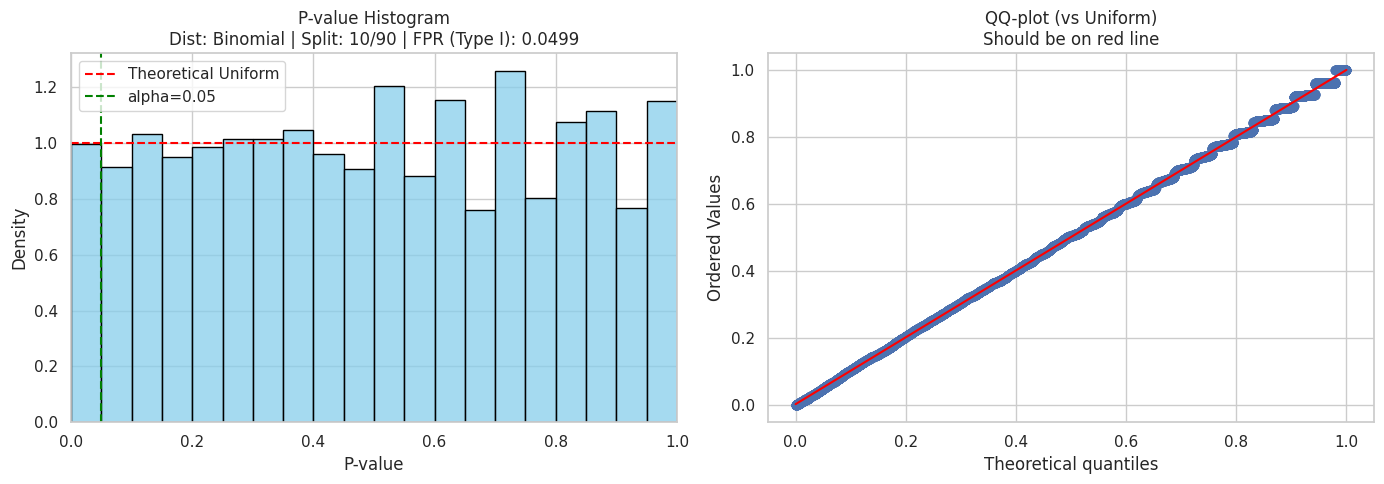

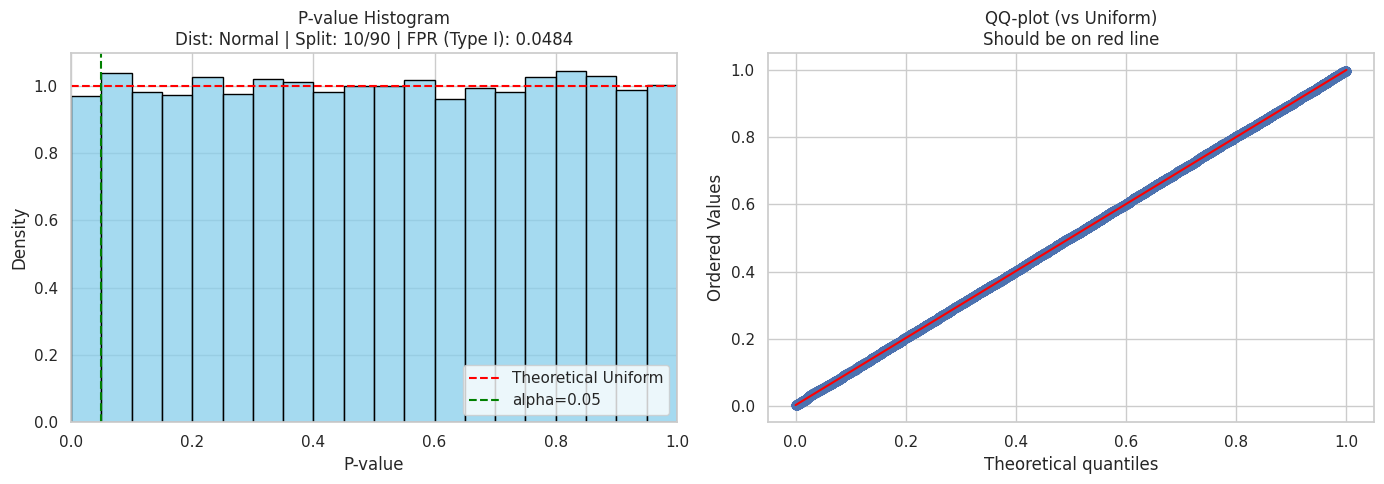

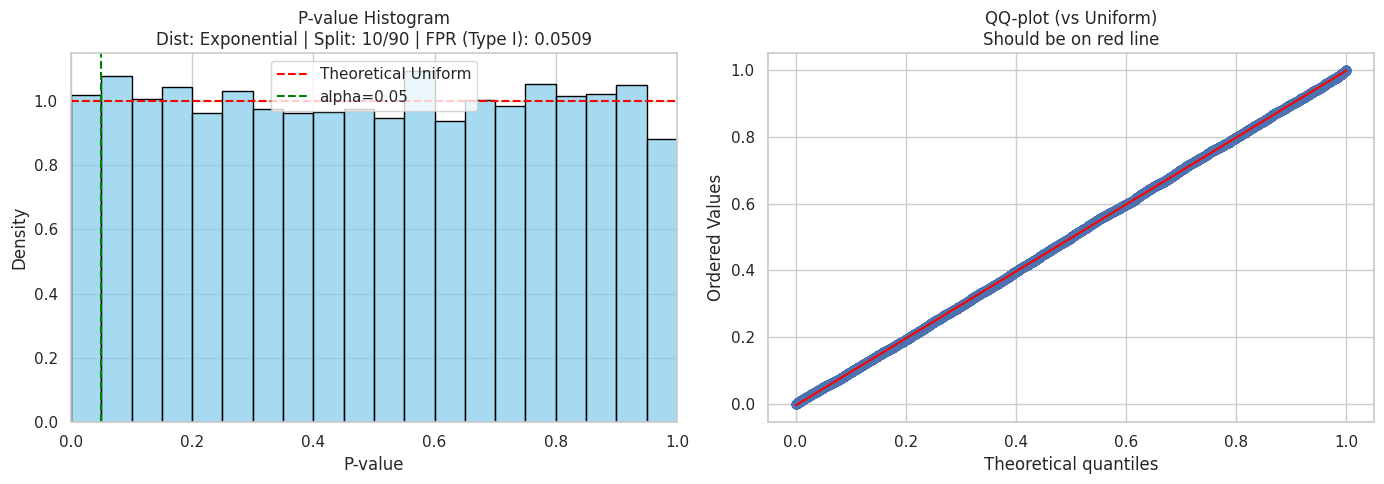

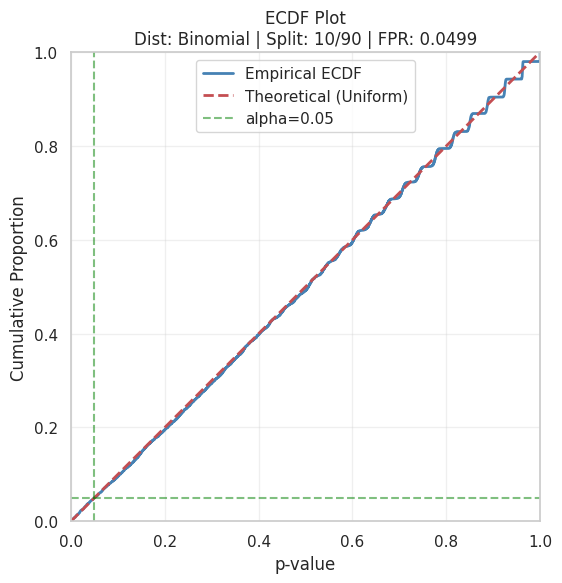

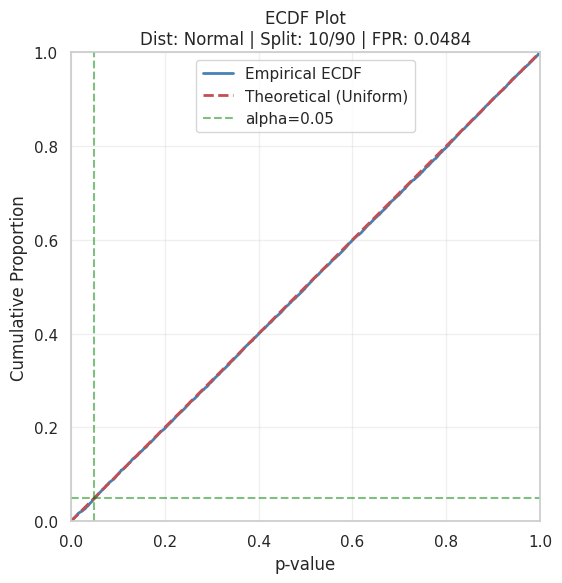

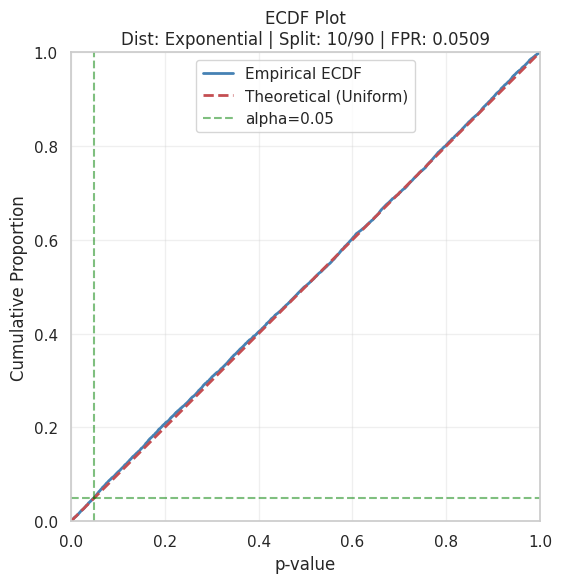

In [ ]:
split_str = '10/90'
alpha = 0.05
# графики на ошибку первого рода
for nice_name, p_values, fpr in results_50_50:
    plot_results(p_values, nice_name, split_str, fpr, alpha=alpha)
# график на ECDF
for nice_name, p_values, fpr in results_50_50:
    plot_ecdf(p_values, nice_name, split_str, fpr, alpha=alpha)

In [ ]:
# Удаляем старые массивы из оперативной памяти
try:
    del results_50_50, results_10_90, p_values
    gc.collect()
except NameError:
    pass

Вывод простой - практическое ложится идеально на эмпирическое

A/B test


In [ ]:
# новая def run_ab_test
# чтобы снова переиспользовать def data_generator()
def run_ab_test(n_simulations: int, data_generator, alpha: float = 0.05):
  p_values = []

  for _ in tqdm(range(n_simulations)):
    samples_control, samples_test = data_generator()

    # тут мы критерием t-test Welch проверяем есть ли эффект или нет
    _, p_val = stats.ttest_ind(samples_control, samples_test, equal_var=False)
    p_values.append(p_val)


  # del samples_control, samples_test

  # вне цикла, иначе кабзда
  # gc.collect()

  # подсчет false negative rate - тоесть какая доля того,
  # что критерий не заметил эффект, хотя он был
  fnr = np.mean(np.array(p_values) > alpha)
  return p_values, fnr



def get_theoretical_beta(alpha, mde, std, n_per_group):
    """
    Считает теоретическую ошибку 2-го рода (Beta) для t-теста.
    Формула приближенная для двустороннего теста.
    """
    # Стандартная ошибка разности средних (при equal size и equal var)
    se = np.sqrt(2 * (std**2) / n_per_group)

    # Критическое значение Z для ошибки 1-го рода (alpha)
    z_alpha = stats.norm.ppf(1 - alpha / 2)

    # Z-score, соответствующий мощности
    # MDE = (z_alpha + z_beta) * SE
    # z_beta = MDE/SE - z_alpha
    z_beta = (mde / se) - z_alpha

    # Мощность (Power) = P(Z < z_beta)
    power = stats.norm.cdf(z_beta)

    return 1 - power  # Beta

Случай с нормальным распределением


In [ ]:
# случай нормального распределения, где добавили эффект
mde_norm = 2
mu = 100
sigma = 15
sample_sizes_norm = np.arange(100, 5000, 300) # 100, 400, 700, 1000, 1300 ...
n_sims = 1000
alpha = 0.05
betas_sim_norm = []
betas_theo_norm = []
split_ratio = 0.5
#симуляция
print("Симуляция аб тестирования для нормального распределения, замеряем мощность")
print("split_ratio = 0.5")
for n in tqdm(sample_sizes_norm):
  # n_curr = n #<-- чтоб лямбда типо запомнила значение на шаге N
  # костыль
  gen_norm = lambda n_curr=n: data_generator(
      type_dist="norm",
      n_samples_both=n_curr,
      split_ratio=split_ratio,
      mde=mde_norm,
      mu_normal=mu,
      sigma_normal=sigma
  )

  #эмпирически посчитанно
  _, fnr = run_ab_test(n_sims, gen_norm, alpha)
  betas_sim_norm.append(fnr)
  # теоретически
  b_theo = get_theoretical_beta(alpha, mde_norm, sigma, n_per_group=n//2)
  betas_theo_norm.append(b_theo)

Симуляция аб тестирования для нормального распределения, замеряем мощность
split_ratio = 0.5


100%|██████████| 17/17 [00:47<00:00,  2.82s/it]


/tmp/ipykernel_4246/1562822804.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax.plot(sample_sizes_norm, betas_theo_norm, 'r--', label='Theoretical', color='red')


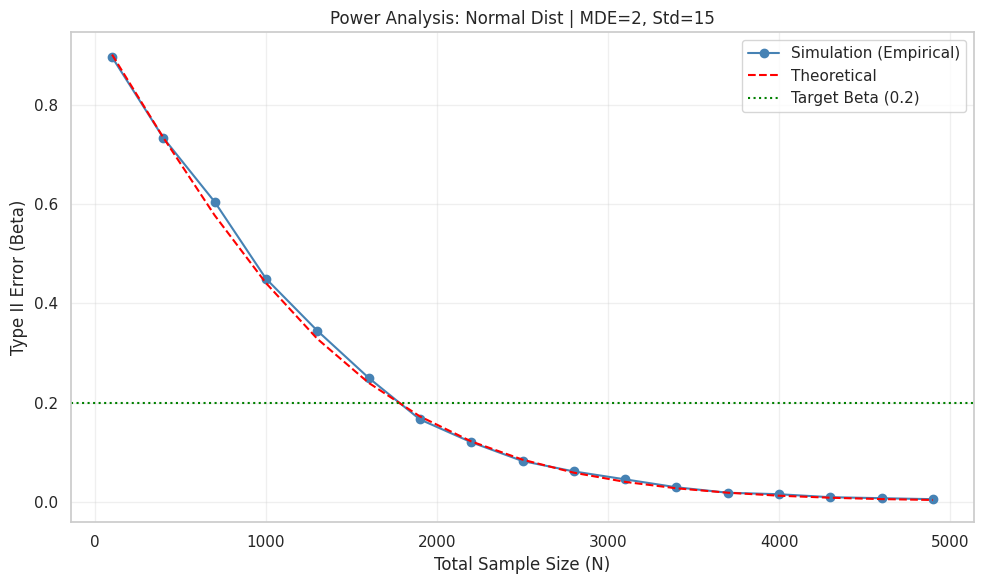

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Симуляция
ax.plot(sample_sizes_norm, betas_sim_norm, 'o-', label='Simulation (Empirical)', color='steelblue')
# Теория
ax.plot(sample_sizes_norm, betas_theo_norm, 'r--', label='Theoretical', color='red')

# Линия целевой мощности ( Beta < 0.2)
ax.axhline(0.2, color='green', linestyle=':', label='Target Beta (0.2)')

ax.set_title(f"Power Analysis: Normal Dist | MDE={mde_norm}, Std={sigma}")
ax.set_xlabel("Total Sample Size (N)")
ax.set_ylabel("Type II Error (Beta)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

In [ ]:
try:
    del betas_theo_norm, betas_sim_norm, p_values
    gc.collect()
except NameError:
    pass

случай с биномиальным распределением
c разбиением 50 на 50

In [ ]:
p_base = 0.1
mde_bin = 0.03 # прирост на 3%
std_bin = np.sqrt(p_base * (1 - p_base))
sample_sizes_bin = np.arange(100, 5000, 300)
n_sims = 1000
alpha = 0.05
split_ratio = 0.5

betas_sim_bin = []
betas_theo_bin = []
split_ratio = 0.5
print("симуляция аб для биномиального, сплит 50 на 50")
for n in tqdm(sample_sizes_bin):
  # костыль снова
  gen_bin = lambda n_curr = n: data_generator(
      type_dist="binom",
      n_samples_both=n_curr,
      split_ratio=split_ratio,
      mde=mde_bin,
      p_conversion=p_base
  )

  # simulation
  _, fnr = run_ab_test(n_sims, gen_bin, alpha)
  betas_sim_bin.append(fnr)
  # theoretical betas by t-distribution
  b_theo = get_theoretical_beta(alpha, mde_bin, std_bin, n_per_group=n // 2)
  betas_theo_bin.append(b_theo)

симуляция аб для биномиального, сплит 50 на 50


100%|██████████| 33/33 [01:26<00:00,  2.61s/it]


/tmp/ipykernel_4246/1825179704.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax.plot(sample_sizes_bin, betas_theo_bin, 'r--', label='Theoretical', color='red')


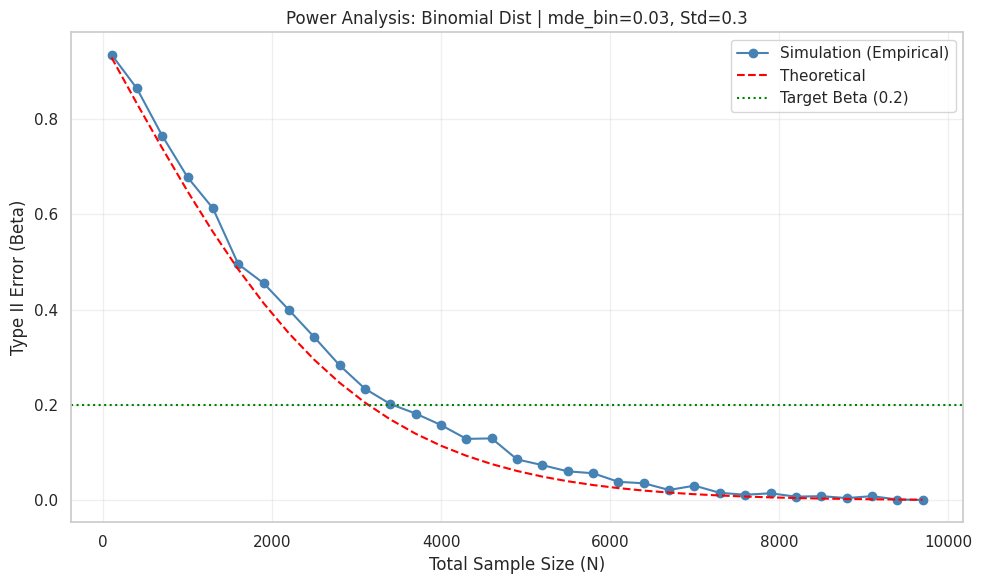

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Симуляция
ax.plot(sample_sizes_bin, betas_sim_bin, 'o-', label='Simulation (Empirical)', color='steelblue')
# Теория
ax.plot(sample_sizes_bin, betas_theo_bin, 'r--', label='Theoretical', color='red')

# Линия целевой мощности (обычно хотят Beta < 0.2)
ax.axhline(0.2, color='green', linestyle=':', label='Target Beta (0.2)')

ax.set_title(f"Power Analysis: Binomial Dist | mde_bin={mde_bin}, Std={std_bin:.2}")
ax.set_xlabel("Total Sample Size (N)")
ax.set_ylabel("Type II Error (Beta)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

In [ ]:
try:
    del betas_sim_bin, betas_theo_bin
    gc.collect()
except NameError:
    pass

Эмпирическая Beta выше теоретической на всём диапазоне.
   - Причина: дискретность данных (0/1) + t-тест консервативнее Z-теста + Использовался тест Уэлча который не знает о равенстве дисперсий
   

Импортируем свой теоретические калькулятор

In [ ]:
from statsmodels.stats.power import GofChisquarePower
import statsmodels.api as sm

# Рассчитываем размер эффекта
effect_size = sm.stats.proportion_effectsize(0.13, 0.10)

# Рассчитываем количество сэмплов
sample_size = sm.stats.NormalIndPower().solve_power(
    effect_size=effect_size,
    alpha=0.05,
    power=0.8,
    ratio=1
)

print(f"Размер выборки на одну группу: {round(sample_size)}")

Размер выборки на одну группу: 1768


p_a = 0.13 p_0 = 0.1 beta = 0.2 alpha = 0.05 => n = 1768
ага, значит не сходится

от того что выше как раз можно построить заисимость mde от N

просто калькулятор https://www.statsig.com/calculator но он брешет


In [ ]:
def get_theoretical_beta_correct(alpha, p_control, p_test, n_per_group):
    """
    Считает теоретическую Beta СПЕЦИАЛЬНУЮ для биномиального распределения, потому
    что прошла def get_theoretical и учитывает неравные дисперсии
    лучше считать честную SE.

    Почему? ответ ниже
    """
    # Дисперсия контроля
    var_c = p_control * (1 - p_control)
    # Дисперсия теста (она больше!)
    var_t = p_test * (1 - p_test)

    # Правильная стандартная ошибка разности
    se = np.sqrt(var_c / n_per_group + var_t / n_per_group)

    # MDE (разница средних)
    delta = np.abs(p_test - p_control)

    z_alpha = stats.norm.ppf(1 - alpha / 2)

    # z_beta calculation
    z_beta = (delta / se) - z_alpha

    power = stats.norm.cdf(z_beta)
    return 1 - power

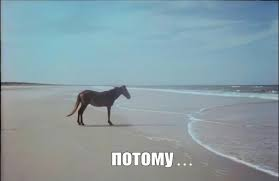


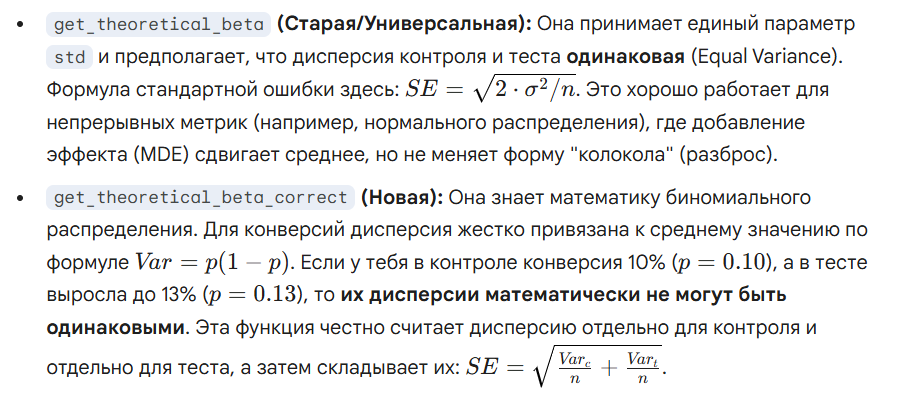

In [ ]:
betas_sim_bin = []
betas_theo_bin = []

sample_sizes_bin = np.arange(100, 5000, 300)
n_sims = 1000
for n in tqdm(sample_sizes_bin):

  gen_bin = lambda n_curr = n: data_generator(
      type_dist="binom",
      n_samples_both=n_curr,
      split_ratio=split_ratio,
      mde=mde_bin,
      p_conversion=p_base
  )

  # simulation
  _, fnr = run_ab_test(n_sims, gen_bin, alpha)
  betas_sim_bin.append(fnr)

  # theoretical betas (ИСПРАВЛЕННЫЙ ВЫЗОВ)
  # Передаем p_base и (p_base + mde_bin) явно
  b_theo = get_theoretical_beta_correct(
      alpha,
      p_control=p_base,
      p_test=p_base + mde_bin,
      n_per_group=n // 2
  )
  betas_theo_bin.append(b_theo)

100%|██████████| 17/17 [00:38<00:00,  2.28s/it]


/tmp/ipykernel_4246/1274073642.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax.plot(sample_sizes_bin, betas_theo_bin, 'r--', label='Theoretical', color='red')


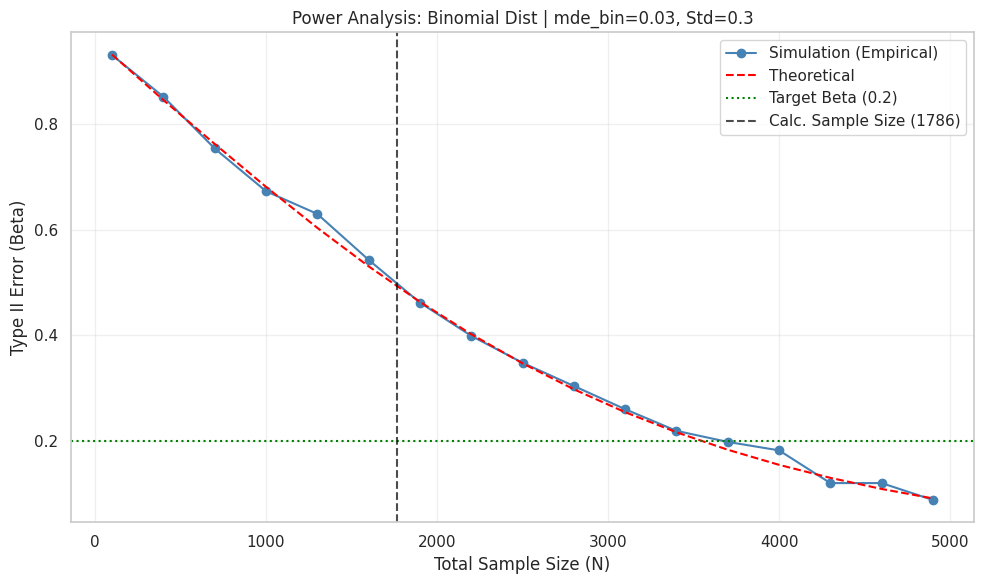

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Симуляция
ax.plot(sample_sizes_bin, betas_sim_bin, 'o-', label='Simulation (Empirical)', color='steelblue')
# Теория sample_sizes_bin
ax.plot(sample_sizes_bin, betas_theo_bin, 'r--', label='Theoretical', color='red')

# Линия целевой мощности (обычно хотят Beta < 0.2)
ax.axhline(0.2, color='green', linestyle=':', label='Target Beta (0.2)')
ax.axvline(x=1768, color='black', linestyle='--', alpha=0.7, label='Calc. Sample Size (1786)')

ax.set_title(f"Power Analysis: Binomial Dist | mde_bin={mde_bin}, Std={std_bin:.2}")
ax.set_xlabel("Total Sample Size (N)")
ax.set_ylabel("Type II Error (Beta)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

In [ ]:
try:
    del betas_sim_bin, betas_theo_bin, sample_sizes_bin, n_sims
    gc.collect()
except NameError:
    pass

Теперь посмотрим как растет ошибка второго рода, когда при том же количестве сэмплов увеличивается дисперсия тестового распределения.

Возьмем нормальное распределение, две группы, в тесте есть MDE 30%, сэмплов по 2000 в control and test и sigma_control and sigma_test будут увеличиваться на 1 до 10

строим эмпирический график и теоретический


In [ ]:
iter_vector_sigmas = np.arange(1, 50, 1)
fnr_empirical = []
fnr_theo = []
mu_control = 10
mde = 3
alpha = 0.05
size_samples_both = 2000

n_simulations = 500 # <--- тоесть мы считаем 500 раз fnr генеря 2000 сэплов для теста и контроля, тоесть по 1000 на тест и котрол при четко заданной дисперсии


# эпирически Монте-карло, считаем ошибку второго рода на 2000 сэмплов, повышая каждый раз дисперсию для теста и контрола
print("Запускаем расчет Ошибки 2-го рода от роста дисперсии...")
for sigma in tqdm(iter_vector_sigmas, desc="Перебор дисперсий (Sigma)"):

    gen_norm = lambda s=sigma: data_generator(
        type_dist="norm",
        n_samples_both=size_samples_both
        split_ratio=0.5,
        mde=mde,
        mu_normal=mu_control,
        sigma_normal=s
    )

    # Эмпирически считаем ошибку 2-го рода (run_ab_test крутит цикл внутри себя)
    _, fnr_emp = run_ab_test(n_simulations, gen_norm, alpha)
    fnr_empirical.append(fnr_emp)

    # Теоретически
    beta_theo = get_theoretical_beta(alpha=alpha, mde=mde, std=sigma, n_per_group=size_samples_both)
    fnr_theo.append(beta_theo)

Запускаем расчет Ошибки 2-го рода от роста дисперсии...


Перебор дисперсий (Sigma): 100%|██████████| 49/49 [00:56<00:00,  1.16s/it]


/tmp/ipykernel_4246/4152217452.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax.plot(iter_vector_sigmas, fnr_theo, 'r--', label='Theoretical', color='red')


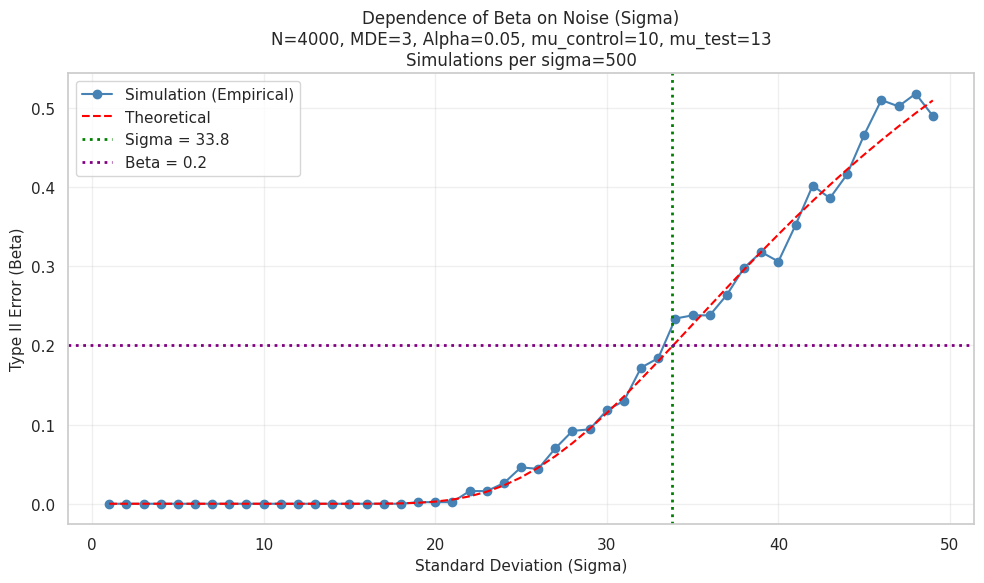

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(iter_vector_sigmas, fnr_empirical, 'o-', label='Simulation (Empirical)', color='steelblue')
ax.plot(iter_vector_sigmas, fnr_theo, 'r--', label='Theoretical', color='red')

# Добавляем вертикальную линию на sigma = 34 (33.8 - расчетная точка для Beta=0.2)
ax.axvline(x=33.8, color='green', linestyle=':', linewidth=2, label='Sigma = 33.8')

# Добавляем горизонтальную линию на Beta = 0.2
ax.axhline(y=0.2, color='purple', linestyle=':', linewidth=2, label='Beta = 0.2')

ax.set_title(f"Dependence of Beta on Noise (Sigma)\nN={size_samples_both}, MDE={mde}, Alpha={alpha}, mu_control={mu_control}, mu_test={mu_control + mde}\nSimulations per sigma={n_simulations}", fontsize=12)
ax.set_xlabel("Standard Deviation (Sigma)", fontsize=11)
ax.set_ylabel("Type II Error (Beta)", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

Возьмем такую сигму, которая удовлетворяет теоритечески
это будет 33.8
Тоесть при сигма 33.8, N=2000, alpha = 0.05, power = 1 - beta = 0.8 удовлетворяет
Построим графики распределения p-value и QQ-plot, ecdf plot

Для N=2000 и MDE=3 при Power=80% предельная Sigma = 33.86
Запускаем симуляцию идеального A/B теста (5000 итераций)...


100%|██████████| 5000/5000 [00:15<00:00, 324.40it/s]


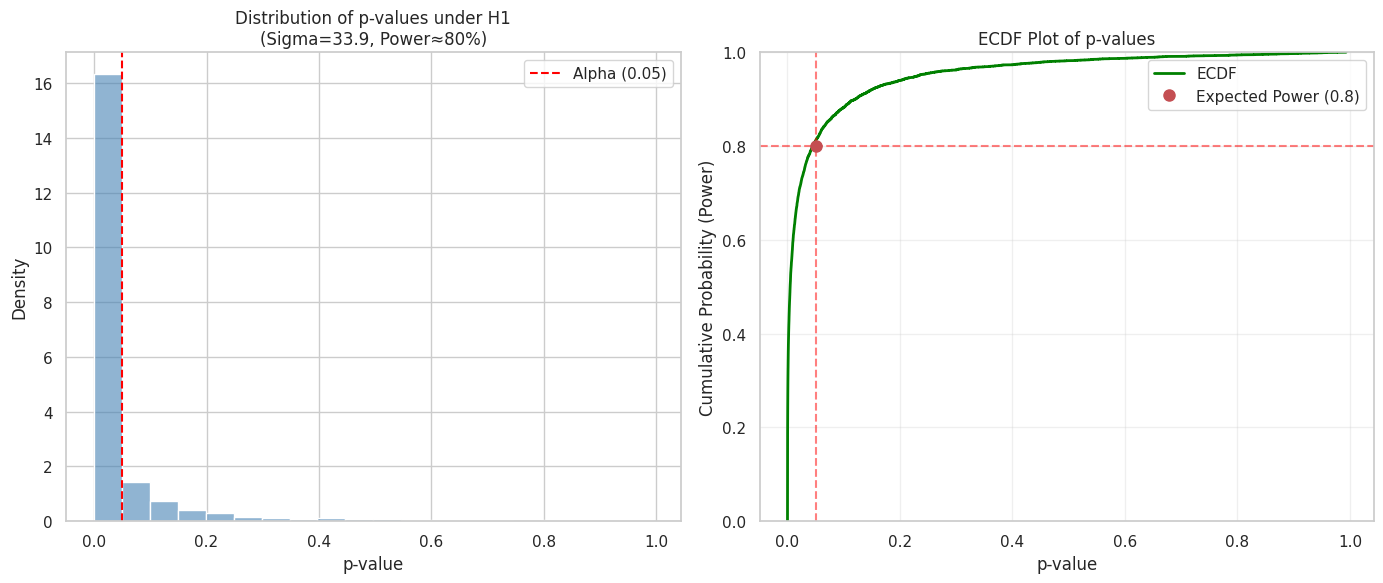

Эмпирическая мощность (доля p-value < 0.05): 0.811


In [ ]:
alpha = 0.05
target_beta = 0.2
n_per_group = 2000
mde = 3
mu_control = 10

# 1. Формула: N = 2 * sigma^2 * (Z_alpha + Z_beta)^2 / MDE^2
# Выражаем Sigma: sigma = sqrt( N * MDE^2 / (2 * (Z_alpha + Z_beta)^2) )

z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta = stats.norm.ppf(1 - target_beta)
required_sigma = np.sqrt( (n_per_group * mde**2) / (2 * (z_alpha + z_beta)**2) )

print(f"Для N={n_per_group} и MDE={mde} при Power=80% предельная Sigma = {required_sigma:.2f}")

# 2. Создаем "идеальный" генератор данных
n_simulations = 5000

generate_for_perfect_sigma = lambda: data_generator(
    type_dist="norm",
    n_samples_both=n_per_group * 2, # Передаем общий размер (4000)
    split_ratio=0.5,
    mde=mde,
    mu_normal=mu_control,
    sigma_normal=required_sigma
)

# 3. Генерируем p-values для этого случая
print(f"Запускаем симуляцию идеального A/B теста ({n_simulations} итераций)...")
p_values, _ = run_ab_test(n_simulations, generate_for_perfect_sigma, alpha)

p_values = np.array(p_values)

# --- 4. Рисуем графики по ТЗ ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Распределение P-values (Гистограмма)
# При наличии эффекта (H1) гистограмма должна быть прижата к левому краю (к нулю).
sns.histplot(p_values, bins=20, ax=axes[0], stat='density', color='steelblue', alpha=0.6)
axes[0].axvline(0.05, color='red', linestyle='--', label='Alpha (0.05)')
axes[0].set_title(f'Distribution of p-values under H1\n(Sigma={required_sigma:.1f}, Power≈80%)')
axes[0].set_xlabel('p-value')
axes[0].legend()

# График 2: ECDF (Эмпирическая кумулятивная функция)
# Показывает, какая доля p-value меньше определенного X.
# В точке X=0.05 график должен проходить через Y=0.8 (наша Мощность).
sns.ecdfplot(p_values, ax=axes[1], color='green', linewidth=2, label='ECDF')

# Рисуем перекрестие в точке (0.05, 0.8)
axes[1].axvline(0.05, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(1 - target_beta, color='red', linestyle='--', alpha=0.5)
axes[1].plot(0.05, 1 - target_beta, 'ro', markersize=8, label=f'Expected Power ({1-target_beta})')

axes[1].set_title('ECDF Plot of p-values')
axes[1].set_xlabel('p-value')
axes[1].set_ylabel('Cumulative Probability (Power)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close(fig) # Очищаем память

# Проверка цифрами
real_power = np.mean(p_values < alpha)
print(f"Эмпирическая мощность (доля p-value < 0.05): {real_power:.3f}")

1. Гистограмма (Distribution of p-values under H1)
Что здесь происходит:
Мы провели 5000 А/Б тестов. В каждом тесте мы получили какое-то p-value. Этот график показывает, как часто выпадали разные значения p-value.
Высокий столбец слева (от 0 до 0.05): Это зона "статистической значимости".
Поскольку мы знаем, что разница между группами есть (
MDE=3
), мы ожидаем, что тест будет часто "кричать" об этом, выдавая маленькие p-value.
Если бы эффекта не было (А/А тест), все столбцы были бы примерно одной высоты (равномерное распределение). Но здесь мы видим огромный перекос влево.

2. ECDF Plot (Кумулятивная функция распределения)
Что здесь происходит:
Этот график отвечает на вопрос: "Какова вероятность получить p-value меньше определенного числа X?".
Это самый важный график для проверки Мощности (Power).
Ось X: Значение p-value (нас интересует точка 0.05, красная вертикальная пунктирная линия).
Ось Y: Доля тестов (от 0 до 1), которые попали в этот диапазон.
Красная точка (перекрестие):
Координата X = 0.05 (наш уровень значимости
α
α
).
Координата Y = 0.8 (наша целевая мощность
1
−
β
1−β
).

### CI t-test Welch vs CI Bootstrap

5. Построить доверительный интервал т-тестом уэлча и бутстрапировать выборку, чтобы оценить MDE

- Проведем симуляцию с нормальным распределением, зная какое будет MDE, затем оценим его Доверительным интервалом и бутстрапом
-  Мы предполагаем, что данные распределены нормально, считаем стандартную ошибку (SE) по формуле и строим интервал: Effect±1.96⋅SE
где эффект эмпирически высчитанная разность средних между тестом и контролем
- но бустрапом мы имитируем, что разница средних распределена нормально и уже на нормальном распределении бутсрапированного оценочного MDE мы строим доверительный интервал

100%|██████████| 5000/5000 [07:39<00:00, 10.89it/s]



Результаты Coverage Probability (должно быть около 0.95):
T-test (Analytic) Coverage: 0.946
Bootstrap Coverage:         0.943
@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
95% CI (Bootstrap):    [0.4409, 4.7652]
Разница средних (из теста): 2.5419
Стандартная ошибка (SE):    1.0587
------------------------------
95% Доверительный интервал: [0.4669, 4.6169]

Успех! Истинный эффект MDE=3 лежит внутри интервала.

Успех! MDE=3 лежит в бутстрапированном доверительного интервала


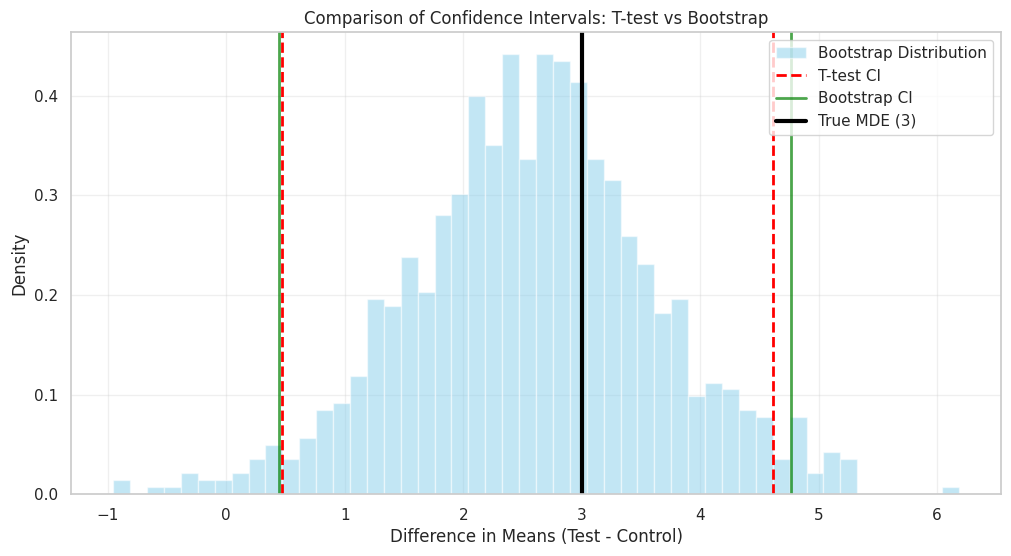

In [ ]:
mu_control = 10
mde = 3
mu_test = 13
sigma = 33.9
n = 2000
alpha = 0.05

np.random.seed(45)
# эксперимент HUGE CYCLE
n_simulation = 500
n_succes_ttest_CI = 0
n_succes_bootstrap_CI = 0

for k in tqdm(range(n_simulations)):

  control = np.random.normal(mu_control, sigma, n)
  test = np.random.normal(mu_test, sigma, n)

  # расчет SE
  var_c = np.var(control, ddof=1)
  var_t = np.var(test, ddof=1)
  se_manual = np.sqrt(var_c/n + var_t/n)

  res = stats.ttest_ind(test, control, equal_var=False)

  # Доверительный интервал
  diff = np.mean(test) - np.mean(control)
  z = stats.norm.ppf(1-alpha/2)
  ci_low_t = diff - z * se_manual
  ci_high_t = diff + z * se_manual


  # Доверительный интервал через Бутстрап
  n_boot_samples = 1000
  boot_diffs = []

  for _ in range(n_boot_samples):
    # выборка с возвращением (replace=True)
    c_boot = np.random.choice(control, size=n, replace=True)
    t_boot = np.random.choice(test, size=n, replace=True)

    # бутсрапированные данные из которых считается бустрапированная разность
    diff = np.mean(t_boot) - np.mean(c_boot)
    boot_diffs.append(diff)

  # перцентили (2.5 и 97.5) так как двух сторонний доверит интервал
  conf_int_boot = np.percentile(boot_diffs, [2.5, 97.5])

  # подсчет доли того, что доверительные интервалы поймали
  if ci_low_t <= mde <= ci_high_t:
    n_succes_ttest_CI += 1
  if conf_int_boot[0] <= mde <= conf_int_boot[1]:
    n_succes_bootstrap_CI += 1

print("\nРезультаты Coverage Probability (должно быть около 0.95):")
print(f"T-test (Analytic) Coverage: {n_succes_ttest_CI / n_simulations:.3f}")
print(f"Bootstrap Coverage:         {n_succes_bootstrap_CI / n_simulations:.3f}")
print('@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@')

print(f"95% CI (Bootstrap):    [{conf_int_boot[0]:.4f}, {conf_int_boot[1]:.4f}]")
# вывод
print(f"Разница средних (из теста): {np.mean(test) - np.mean(control):.4f}")
print(f"Стандартная ошибка (SE):    {se_manual:.4f}")
print("-" * 30)
print(f"95% Доверительный интервал: [{ci_low_t:.4f}, {ci_high_t:.4f}]")

# Проверка
if ci_low_t <= mde <= ci_high_t:
    print(f"\nУспех! Истинный эффект MDE={mde} лежит внутри интервала.")
else:
    print("\nЭффект не попал в интервал.")

if conf_int_boot[0] <= mde <= conf_int_boot[1]:
  print(f"\nУспех! MDE={mde} лежит в бутстрапированном доверительного интервала")
else:
  print("\nЭффект не попал в бутстрапированный интервал.")

#ОТРИСОВКА

plt.figure(figsize=(12, 6))

# А. Гистограмма распределения разниц (из бутстрапа)
plt.hist(boot_diffs, bins=50, density=True, alpha=0.5, color='skyblue', label='Bootstrap Distribution')

# Б. Засечки T-теста (Красные пунктирные)
plt.axvline(ci_low_t, color='red', linestyle='--', linewidth=2, label='T-test CI')
plt.axvline(ci_high_t, color='red', linestyle='--', linewidth=2)

# В. Засечки Бутстрапа (Зеленые сплошные)
# Они скорее всего наложатся на красные, так как распределение нормальное
plt.axvline(conf_int_boot[0], color='green', linestyle='-', linewidth=2, alpha=0.7, label='Bootstrap CI')
plt.axvline(conf_int_boot[1], color='green', linestyle='-', linewidth=2, alpha=0.7)

# Г. Истинный эффект (Черная линия)
plt.axvline(mde, color='black', linewidth=3, label=f'True MDE ({mde})')

plt.title('Comparison of Confidence Intervals: T-test vs Bootstrap')
plt.xlabel('Difference in Means (Test - Control)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()
plt.close(fig)

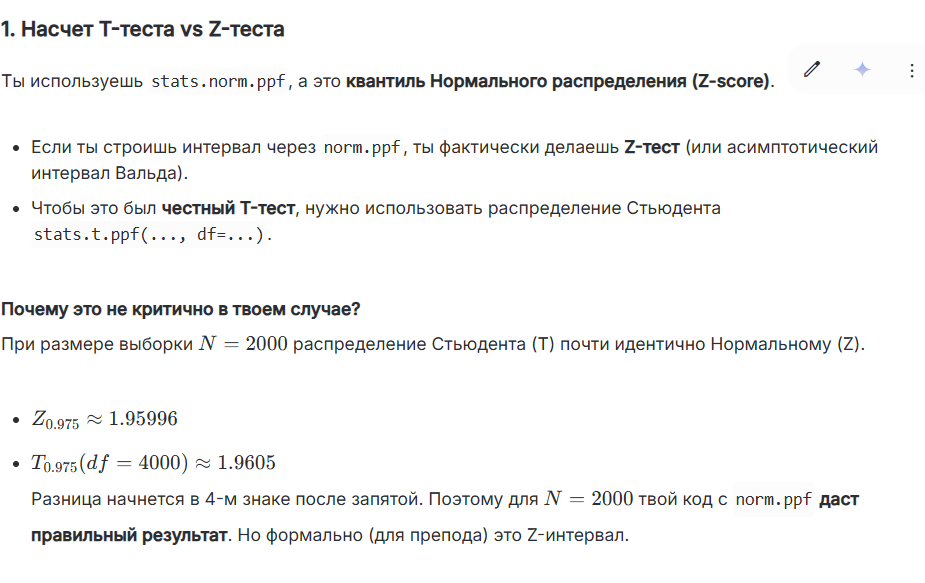

Покажем зависимость MDE от N

/tmp/ipykernel_164/729693312.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mde = float(es) * sigma


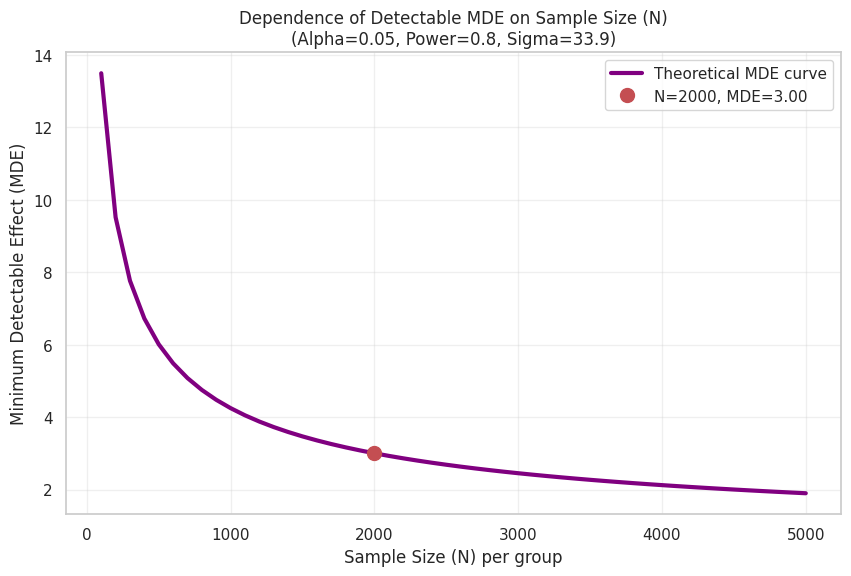

При выборке N=2000 минимально детектируемый эффект MDE = 3.004


In [ ]:
from statsmodels.stats.power import TTestIndPower

# --- 1. Параметры ---
alpha = 0.05
power = 0.8
sigma = 33.9

# Диапазон размеров выборки (N)
n_values = np.arange(100, 5100, 100)
mde_values = []

# Инициализируем класс
analysis = TTestIndPower()

for n in n_values:

    es = analysis.solve_power(
        effect_size=None,
        nobs1=n,
        alpha=alpha,
        power=power,
        ratio=1.0
    )

    mde = float(es) * sigma
    mde_values.append(mde)


mde_values = np.array(mde_values)


plt.figure(figsize=(10, 6))

plt.plot(n_values, mde_values, linewidth=3, color='purple', label='Theoretical MDE curve')

# Оформление
plt.title(f'Dependence of Detectable MDE on Sample Size (N)\n(Alpha={alpha}, Power={power}, Sigma={sigma})')
plt.xlabel('Sample Size (N) per group')
plt.ylabel('Minimum Detectable Effect (MDE)')
plt.grid(True, alpha=0.3)
plt.legend()


check_n = 2000
idx = np.where(n_values == check_n)[0][0]
check_mde = mde_values[idx]

plt.plot(check_n, check_mde, 'ro', markersize=10, label=f'N={check_n}, MDE={check_mde:.2f}')
plt.legend()

plt.show()

print(f"При выборке N={check_n} минимально детектируемый эффект MDE = {check_mde:.3f}")

A/B test cuped


Подготовительные фукнции:
- def build_cov_matrix
- def ready_data_cupeds_for_tests <- генерирует зависимые и сразу применяет Cuped`ы, когда написал ёё стало лень разбивать на две

In [ ]:
# Строим ковариационную матрицу для np.random.multivariate_normal
def build_cov_matrix(
    dimensions: int,
    var_y: float = 1.0, var_x1: float = 1.0, corr_y_x1: float = 1.0,
    var_x_2: float = 1.0, corr_y_x2: float = 0.0, corr_x1_x2: float = 0.0
) -> list:

  """
  corr принимает от [-1, 1]
  dimeshions принимает только 2 и только 3
  Y - метрика, X1 - ковариата первая, X2 - ковариата 2
  return covariate_matrix
  """
  # проверка значений корреляций
  assert all(abs(x) <= 1 for x in [corr_y_x1, corr_y_x2, corr_x1_x2])

  std_y = np.sqrt(var_y)
  std_x1 = np.sqrt(var_x1)
  # ковариация между Y и X1
  cov_y_x1 = corr_y_x1 * std_y * std_x1

  if dimensions == 2:
    covariate_matrix = [ [var_y, cov_y_x1],
                        [cov_y_x1, var_x1]]
  elif dimensions == 3:
    std_x2 = np.sqrt(var_x_2)
    cov_y_x2 = corr_y_x2 * std_y * std_x2
    cov_x1_x2 = corr_x1_x2 * std_x1 * std_x2

    covariate_matrix = [ [var_y, cov_y_x1, cov_y_x2],
                        [cov_y_x1, var_x1, cov_x1_x2],
                        [cov_y_x2, cov_x1_x2, var_x_2]]
  else:
    raise ValueError("error, wrong dimensions")

  return covariate_matrix

def ready_data_cupeds_for_tests(
    n_samples: int,
    mde: float,
    build_cov_matrix: list,
    mean_vec: list,
    methods: str = 'standart'
):
  """
  функция генерирует зависимые данные и сразу применяет cuped и мультикьюпед к данным
   функция обладает логикой для standart cuped,
   для cuped_multi_inpended, cuped_multi_iterative
   np.random.multivariate_normal(mean_vec, cov_matrix, n_samples) <-- возвращает матрицу
   в столбцах сгенированные выборки, поэтому делаем слайсы
   mean_vec - массив средние контроля и теста(-ов) (mean(Y), mean(X1), mean(X2))
  """
  mean_vec_control = np.array(mean_vec)
  mean_vec_test = np.array(mean_vec)
  mean_vec_test[0] += mde

  data_ctrl = np.random.multivariate_normal(mean_vec_control, cov = build_cov_matrix, size = n_samples)
  data_test = np.random.multivariate_normal(mean_vec_test, cov = build_cov_matrix, size = n_samples)

  y_ctrl, y_test = data_ctrl[:, 0], data_test[:, 0]
  x1_ctrl, x1_test = data_ctrl[:, 1], data_test[:, 1]

  mean_x1 = np.mean(np.concatenate([x1_ctrl, x1_test]))

  # Проверяем, есть ли третья колонка
  has_x2 = data_ctrl.shape[1] == 3
  if has_x2:
      x2_ctrl, x2_test = data_ctrl[:, 2], data_test[:, 2]
      mean_x2 = np.mean(np.concatenate([x2_ctrl, x2_test]))

  # Логика для обычного cuped с одной ковариатой:
  if methods == 'standart':
    theta = np.cov(x1_ctrl, y_ctrl)[0, 1] / np.var(x1_ctrl, ddof=1) # зачем [0,1] ?
    # САМАЯ ВАЖНАЯ ФОРМУЛА!! Y_cuped = Y - THETA * (X_1 - MEAN_X_1)
    # Применяем к ОБОИМ массивам
    y_cuped_ctrl = y_ctrl - theta * (x1_ctrl - mean_x1)
    y_cuped_test = y_test - theta * (x1_test - mean_x1)

    return y_cuped_ctrl, y_cuped_test

  # Логика для независимого Multi-CUPED
  elif methods == 'multi_independent' and has_x2:
      # Считаем теты независимо друг от друга
      theta1 = np.cov(x1_ctrl, y_ctrl)[0, 1] / np.var(x1_ctrl, ddof=1)
      theta2 = np.cov(x2_ctrl, y_ctrl)[0, 1] / np.var(x2_ctrl, ddof=1)

      # Вычитаем обе ковариаты из Y
      y_multi_ctrl = y_ctrl - theta1 * (x1_ctrl - mean_x1) - theta2 * (x2_ctrl - mean_x2)
      y_multi_test = y_test - theta1 * (x1_test - mean_x1) - theta2 * (x2_test - mean_x2)

      return y_multi_ctrl, y_multi_test

  # Логика для итеративного Multi-CUPED
  elif methods == 'multi_iterative' and has_x2:
      # Сравниваем модули корреляций, чтобы найти лучшую ковариату
      corr1 = np.abs(np.corrcoef(x1_ctrl, y_ctrl)[0, 1])
      corr2 = np.abs(np.corrcoef(x2_ctrl, y_ctrl)[0, 1])
      # выбираем лучшую ковариату
      if corr1 > corr2:
          best_x_ctrl, best_x_test, best_mean = x1_ctrl, x1_test, mean_x1
          sec_x_ctrl, sec_x_test, sec_mean = x2_ctrl, x2_test, mean_x2
      else:
          best_x_ctrl, best_x_test, best_mean = x2_ctrl, x2_test, mean_x2
          sec_x_ctrl, sec_x_test, sec_mean = x1_ctrl, x1_test, mean_x1

      # Итерация 1: CUPED по лучшей ковариате
      theta_best = np.cov(best_x_ctrl, y_ctrl)[0, 1] / np.var(best_x_ctrl, ddof=1)
      y_iter1_ctrl = y_ctrl - theta_best * (best_x_ctrl - best_mean)
      y_iter1_test = y_test - theta_best * (best_x_test - best_mean)

      # Итерация 2: CUPED по второй ковариате, но Y берем УЖЕ ИЗМЕНЕННЫЙ (y_iter1)
      theta_sec = np.cov(sec_x_ctrl, y_iter1_ctrl)[0, 1] / np.var(sec_x_ctrl, ddof=1)
      y_final_ctrl = y_iter1_ctrl - theta_sec * (sec_x_ctrl - sec_mean)
      y_final_test = y_iter1_test - theta_sec * (sec_x_test - sec_mean)

      return y_final_ctrl, y_final_test


  else:
    # Простой А/Б без прикола
    return y_ctrl, y_test

CUPED обязательно нужно применять и к контрольной, и к тестовой группе!

Проверим что cuped, multuped_inpendent, multicuped_iterative не ломаются на А/А тестах
task 1, 4, 5

где одинаковые параметры распределения, alpha = 0.05, критерий уэлча, mde = 0
замеряем FPR - ошибку первого рода

In [ ]:
VAR_Y = 15**2    # Дисперсия метрики
VAR_X1 = 15**2   # Дисперсия 1-й ковариаты
VAR_X2 = 15**2   # Дисперсия 2-й ковариаты

CORR_Y_X1 = 0.6  # Связь метрики с 1-й ковариатой
CORR_Y_X2 = 0.5  # Связь метрики со 2-й ковариатой
CORR_X1_X2 = 0.2 # Связь ковариат между собой

cov_matrix_2x2 = build_cov_matrix(
    dimensions=2, var_y=VAR_Y, var_x1=VAR_X1, corr_y_x1=CORR_Y_X1
)

cov_matrix_3x3 = build_cov_matrix(
    dimensions=3, var_y=VAR_Y, var_x1=VAR_X1, corr_y_x1=CORR_Y_X1,
    var_x_2=VAR_X2, corr_y_x2=CORR_Y_X2, corr_x1_x2=CORR_X1_X2
)

In [ ]:
N_SAMPLES = 2000
N_SIMS = 8000

# кнопки-генераторы standatr cuped
gen_standard = lambda: ready_data_cupeds_for_tests(
    n_samples=N_SAMPLES, mde=0.0, build_cov_matrix=cov_matrix_2x2,
    mean_vec=[100, 100], methods='standart'
)

# independent Multi-CUPED
gen_multi_indep = lambda: ready_data_cupeds_for_tests(
    n_samples=N_SAMPLES, mde=0.0, build_cov_matrix=cov_matrix_3x3,
    mean_vec=[100, 100, 100], methods='multi_independent'
)

# iterative Multi-CUPED
gen_multi_iter = lambda: ready_data_cupeds_for_tests(
    n_samples=N_SAMPLES, mde=0.0, build_cov_matrix=cov_matrix_3x3,
    mean_vec=[100, 100, 100], methods='multi_iterative'
)

# --- ЗАПУСК СИМУЛЯЦИЙ ---
print("Запускаем А/А тесты...")
_, fpr_standart = run_aa_test(N_SIMS, gen_standard, alpha=0.05)
_, fpr_indep = run_aa_test(N_SIMS, gen_multi_indep, alpha=0.05)
_, fpr_iter = run_aa_test(N_SIMS, gen_multi_iter, alpha=0.05)

print(f"FPR Standard CUPED: {fpr_standart:.3f} (должно быть ~0.05)")
print(f"FPR Multi-CUPED Independent: {fpr_indep:.3f} (должно быть ~0.05)")
print(f"FPR Multi-CUPED Iterative: {fpr_iter:.3f} (должно быть ~0.05)")

Запускаем А/А тесты...


100%|██████████| 8000/8000 [00:21<00:00, 366.55it/s]

FPR Standard CUPED: 0.047 (должно быть ~0.05)
FPR Multi-CUPED Independent: 0.052 (должно быть ~0.05)
FPR Multi-CUPED Iterative: 0.047 (должно быть ~0.05)


### Вывод по видам Cuped`ов:
  «Применение метода CUPED ожидаемо не сломало FPR (он остался на уровне 5%), что доказывает корректность метода на А/А тестах. Использование множественных ковариат (Multi-CUPED) позволило еще сильнее снизить дисперсию целевой метрики по сравнению с базовым CUPED (по одной метрике). Итеративный и независимый методы дали схожие результаты. Главный бизнес-вывод: благодаря снижению дисперсии, при фиксированных значениях MDE,
α
 и
β
, требуемый размер выборки
N
 значительно сократился. Это позволяет нам либо проводить тесты быстрее, либо детектировать более мелкие эффекты на том же объеме трафика».

## очень хочется переиспользовать графики для p_value

task 2 и 3

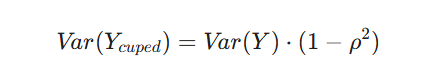

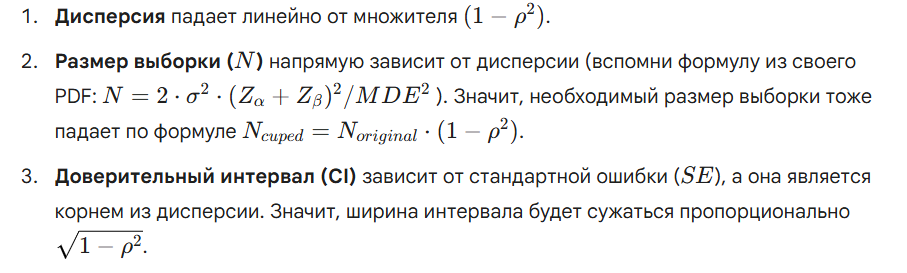

/tmp/ipykernel_465/2436423025.py:75: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(correlations, theoretical_vars, 'r--', color='red', label='Теоретическая: Var * (1 - ρ²)', linewidth=2)
/tmp/ipykernel_465/2436423025.py:83: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(correlations, theoretical_n_sizes, 'r--', color='red', label='Теоретический: N * (1 - ρ²)', linewidth=2)


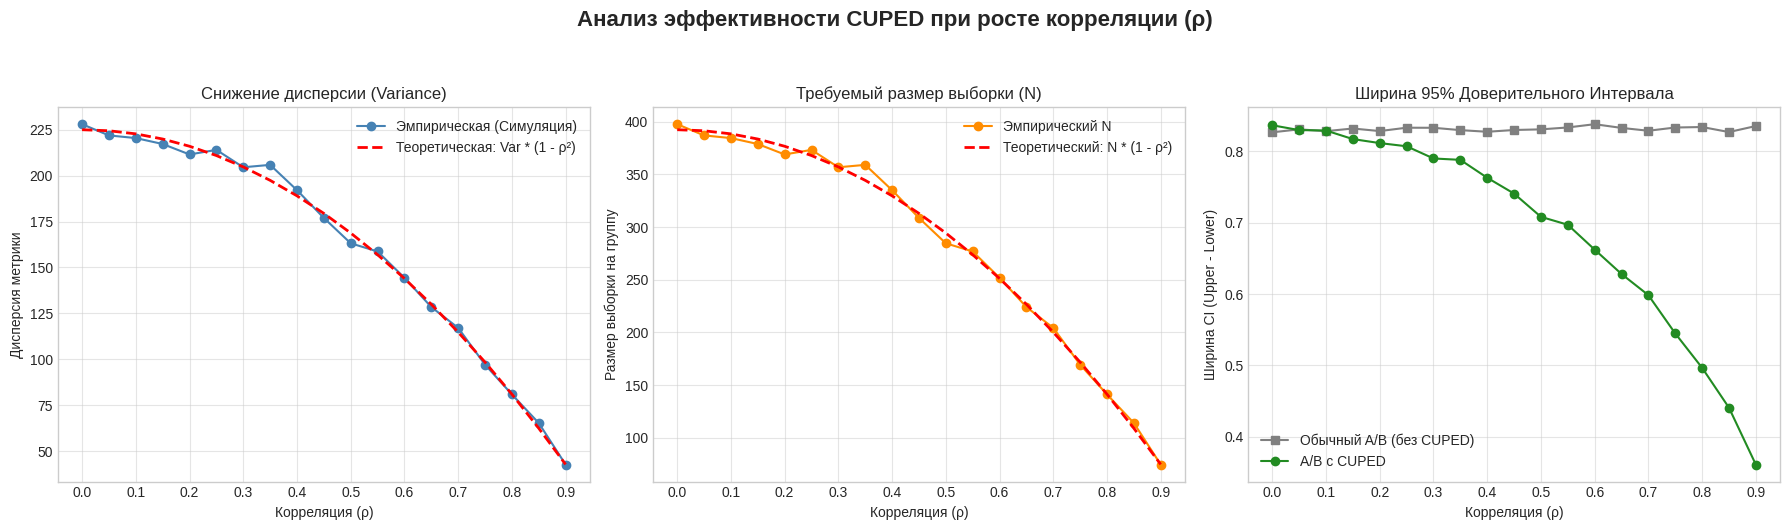

In [ ]:
VAR_Y = 15**2
VAR_X1 = 15**2
MDE = 3.0
N_SAMPLES = 10000

correlations = np.arange(0.0, 0.95, 0.05)

# Списки для сохранения результатов
empirical_vars = []
theoretical_vars = []

empirical_n_sizes = []
theoretical_n_sizes = []

ci_widths_regular = []
ci_widths_cuped = []

# Z-квантили для расчета размера выборки и CI (Alpha = 0.05, Power = 0.8)
z_alpha = stats.norm.ppf(1 - 0.05 / 2)
z_beta = stats.norm.ppf(0.8)

for rho in correlations:
    # СТРОИМ МАТРИЦУ ДЛЯ ТЕКУЩЕГО rho
    cov_matrix = build_cov_matrix(
        dimensions=2, var_y=VAR_Y, var_x1=VAR_X1, corr_y_x1=rho
    )

    # ГЕНЕРИРУЕМ ДАННЫЕ
    # Обычные данные
    y_ctrl_reg, y_test_reg = ready_data_cupeds_for_tests(
        N_SAMPLES, MDE, cov_matrix, [100, 100], methods='none')

    # CUPED данные
    y_ctrl_cuped, y_test_cuped = ready_data_cupeds_for_tests(
        N_SAMPLES, MDE, cov_matrix, [100, 100], methods='standart')

    # ДИСПЕРСИЯ
    # Эмпирическая
    emp_var = np.var(y_ctrl_cuped, ddof=1)
    empirical_vars.append(emp_var)

    # Теоретическая: по формуле
    theo_var = VAR_Y * (1 - rho**2)
    theoretical_vars.append(theo_var)

    # ПУНКТ 2: РАЗМЕР ВЫБОРКИ
    emp_n = 2 * emp_var * (z_alpha + z_beta)**2 / MDE**2
    empirical_n_sizes.append(emp_n)

    # Теоретический: стартовый размер выборки * (1 - rho**2)
    n_original = 2 * VAR_Y * (z_alpha + z_beta)**2 / MDE**2
    theo_n = n_original * (1 - rho**2)
    theoretical_n_sizes.append(theo_n)

    # ПУНКТ 3: ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ
    # Считаем стандартные ошибки (SE) для разницы средних
    se_reg = np.sqrt(np.var(y_ctrl_reg, ddof=1)/N_SAMPLES + np.var(y_test_reg, ddof=1)/N_SAMPLES)
    se_cuped = np.sqrt(np.var(y_ctrl_cuped, ddof=1)/N_SAMPLES + np.var(y_test_cuped, ddof=1)/N_SAMPLES)

    # Ширина интервала - это (Верхняя граница - Нижняя граница)
    # Так как CI = Diff +/- Z * SE, то ширина равна 2 * Z * SE
    ci_widths_regular.append(2 * z_alpha * se_reg)
    ci_widths_cuped.append(2 * z_alpha * se_cuped)

# Настраиваем красивый стиль для графиков
plt.style.use('seaborn-v0_8-whitegrid')

# Создаем полотно с 3 графиками (1 строка, 3 колонки)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Анализ эффективности CUPED при росте корреляции (ρ)', fontsize=16, fontweight='bold', y=1.05)

# --- График 1: Падение дисперсии ---
axes[0].plot(correlations, empirical_vars, 'o-', color='steelblue', label='Эмпирическая (Симуляция)', markersize=6)
axes[0].plot(correlations, theoretical_vars, 'r--', color='red', label='Теоретическая: Var * (1 - ρ²)', linewidth=2)
axes[0].set_title('Снижение дисперсии (Variance)', fontsize=12)
axes[0].set_xlabel('Корреляция (ρ)')
axes[0].set_ylabel('Дисперсия метрики')
axes[0].legend()

# --- График 2: Падение необходимого размера выборки (N) ---
axes[1].plot(correlations, empirical_n_sizes, 'o-', color='darkorange', label='Эмпирический N', markersize=6)
axes[1].plot(correlations, theoretical_n_sizes, 'r--', color='red', label='Теоретический: N * (1 - ρ²)', linewidth=2)
axes[1].set_title('Требуемый размер выборки (N)', fontsize=12)
axes[1].set_xlabel('Корреляция (ρ)')
axes[1].set_ylabel('Размер выборки на группу')
axes[1].legend()

# --- График 3: Сужение доверительного интервала (CI) ---
axes[2].plot(correlations, ci_widths_regular, 's-', color='gray', label='Обычный A/B (без CUPED)', markersize=6)
axes[2].plot(correlations, ci_widths_cuped, 'o-', color='forestgreen', label='A/B с CUPED', markersize=6)
axes[2].set_title('Ширина 95% Доверительного Интервала', fontsize=12)
axes[2].set_xlabel('Корреляция (ρ)')
axes[2].set_ylabel('Ширина CI (Upper - Lower)')
axes[2].legend()

# Финальные штрихи для красоты
for ax in axes:
    ax.set_xticks(np.arange(0.0, 1.0, 0.1)) # Красивые отсечки по оси X
    ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

Task 6


In [ ]:
# Задаем матрицу с двумя ковариатами (X1 коррелирует на 0.6, X2 на 0.5)
VAR_Y = 15**2
VAR_X1 = 15**2
VAR_X2 = 15**2
cov_matrix_3x3 = build_cov_matrix(
    dimensions=3,
    var_y=VAR_Y, var_x1=VAR_X1, corr_y_x1=0.6,
    var_x_2=VAR_X2, corr_y_x2=0.5, corr_x1_x2=0.2 # Ковариаты слабо связаны между собой
)

N_LARGE = 10000
mean_vec = [100, 100, 100]

# Генерируем данные для всех 4-х сценариев
y_none, _ = ready_data_cupeds_for_tests(N_LARGE, 0.0, cov_matrix_3x3, mean_vec, 'none')
y_std, _ = ready_data_cupeds_for_tests(N_LARGE, 0.0, cov_matrix_3x3, mean_vec, 'standart')
y_multi_ind, _ = ready_data_cupeds_for_tests(N_LARGE, 0.0, cov_matrix_3x3, mean_vec, 'multi_independent')
y_multi_iter, _ = ready_data_cupeds_for_tests(N_LARGE, 0.0, cov_matrix_3x3, mean_vec, 'multi_iterative')

print("--- Сравнение дисперсии (Task 6) ---")
print(f"1. Обычный A/B (без CUPED): {np.var(y_none):.2f}")
print(f"2. Стандартный CUPED: {np.var(y_std):.2f}")
print(f"3. Multi-CUPED (Independent): {np.var(y_multi_ind):.2f}")
print(f"4. Multi-CUPED (Iterative): {np.var(y_multi_iter):.2f}")

--- Сравнение дисперсии (Task 6) ---
1. Обычный A/B (без CUPED): 223.17
2. Стандартный CUPED: 145.16
3. Multi-CUPED (Independent): 114.52
4. Multi-CUPED (Iterative): 109.03


Использование одной ковариаты (Стандартный CUPED) снизило дисперсию метрики на $35\%$. Добавление второй ковариаты в Multi-CUPED позволило снизить ее на $49\%$. При этом независимый и итеративный методы показывают практически идентичные результаты снижения дисперсии, так как математически они решают одну и ту же задачу проекции

Запускаем тяжелую симуляцию (может занять пару минут)...


100%|██████████| 14/14 [03:03<00:00, 13.09s/it]


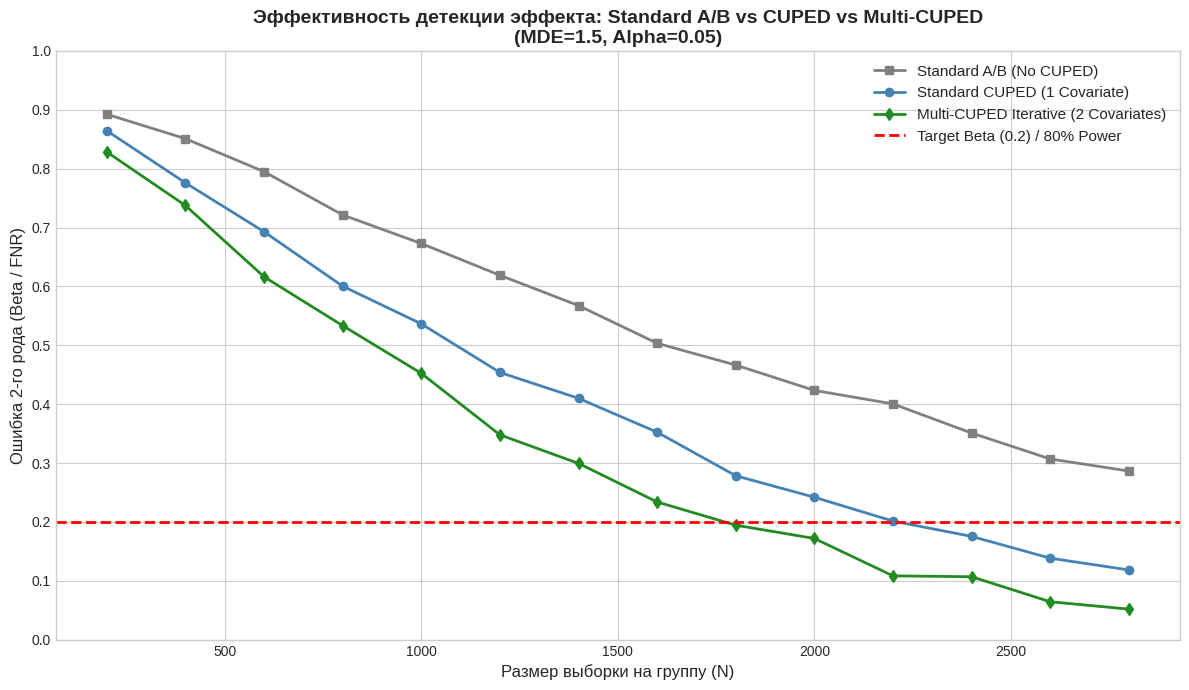

In [ ]:
# Настройки для финального эксперимента
MDE = 1.5      # Небольшой эффект, чтобы было сложнее искать
ALPHA = 0.05
N_SIMS = 2000   # Количество симуляций для каждой точки (поставь 1000-2000 для идеальной гладкости)

# Размеры выборки, по которым мы будем "шагать"
sample_sizes = np.arange(200, 3000, 200)

beta_none = []
beta_std = []
beta_multi = [] # Будем использовать итеративный метод как представителя Multi-CUPED

print("Запускаем тяжелую симуляцию (может занять пару минут)...")
for n in tqdm(sample_sizes):
    p_vals_none = []
    p_vals_std = []
    p_vals_multi = []

    for _ in range(N_SIMS):
        # 1. Обычный A/B
        c_none, t_none = ready_data_cupeds_for_tests(n, MDE, cov_matrix_3x3, mean_vec, 'none')
        p_vals_none.append(stats.ttest_ind(c_none, t_none, equal_var=False)[1])

        # 2. Стандартный CUPED
        c_std, t_std = ready_data_cupeds_for_tests(n, MDE, cov_matrix_3x3, mean_vec, 'standart')
        p_vals_std.append(stats.ttest_ind(c_std, t_std, equal_var=False)[1])

        # 3. Multi-CUPED (Iterative)
        c_multi, t_multi = ready_data_cupeds_for_tests(n, MDE, cov_matrix_3x3, mean_vec, 'multi_iterative')
        p_vals_multi.append(stats.ttest_ind(c_multi, t_multi, equal_var=False)[1])

    # Считаем Ошибку 2-го рода (Beta / FNR) -> доля случаев, когда p_val > alpha (эффект не найден)
    beta_none.append(np.mean(np.array(p_vals_none) > ALPHA))
    beta_std.append(np.mean(np.array(p_vals_std) > ALPHA))
    beta_multi.append(np.mean(np.array(p_vals_multi) > ALPHA))

# ОТРИСОВКА ГРАФИКА
plt.figure(figsize=(12, 7))
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(sample_sizes, beta_none, 's-', color='gray', label='Standard A/B (No CUPED)', linewidth=2)
plt.plot(sample_sizes, beta_std, 'o-', color='steelblue', label='Standard CUPED (1 Covariate)', linewidth=2)
plt.plot(sample_sizes, beta_multi, 'd-', color='forestgreen', label='Multi-CUPED Iterative (2 Covariates)', linewidth=2)

# Добавляем линию желаемой мощности (Beta = 0.2)
plt.axhline(0.2, color='red', linestyle='--', linewidth=2, label='Target Beta (0.2) / 80% Power')
plt.title(f'Эффективность детекции эффекта: Standard A/B vs CUPED vs Multi-CUPED\n(MDE={MDE}, Alpha={ALPHA})', fontsize=14, fontweight='bold')
plt.xlabel('Размер выборки на группу (N)', fontsize=12)
plt.ylabel('Ошибка 2-го рода (Beta / FNR)', fontsize=12)
ax.axvline(x=1768, color='black', linestyle='--', alpha=0.7, label='Calc. Sample Size (1786)')
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

Вывод однозначен: Multi-CUPED >> Standard CUPED >> Standard A/B. Внедрение Multi-CUPED позволит компании проводить эксперименты в $2$ раза быстрее, тестировать больше гипотез в единицу времени и детектировать эффекты, которые раньше считались бы статистически незначимыми из-за высокого уровня шума»